# Import data

Loads every dataset currently in `data/processed/` (plus the
`tourist_cities.json` reference master list) into tidy `pandas`
DataFrames, so exploration/scoring notebooks can start from here
instead of re-writing the same loading code each time.

Run `data/scripts/fetch_*.py` first for anything missing -- each
loader below raises a clear error naming the file it expected if it's
not there yet. See `data/README.md` for what each source is and how
it was fetched.

In [1]:
import json
from pathlib import Path

import pandas as pd

## Paths + helpers

In [2]:
# Notebook lives in notebooks/, data lives in ../data/
DATA_DIR = Path("..") / "data"
PROCESSED_DIR = DATA_DIR / "processed"
REFERENCE_DIR = DATA_DIR / "reference"


def _latest(directory: Path, pattern: str) -> Path:
    """
    Resolve a glob pattern to a file, tolerating filenames that embed a
    year or filter suffix that can change between fetch runs (e.g.
    weather_normals_2025_by_city.json, or the eurostat scripts' filter
    suffixes). Picks the most recently modified match if more than one
    is found, and prints a note when that happens.
    """
    matches = sorted(directory.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    if not matches:
        raise FileNotFoundError(
            f"No file matching {pattern!r} in {directory}/ -- run the "
            f"corresponding fetch script in data/scripts/ first (see data/README.md)."
        )
    if len(matches) > 1:
        print(f"Note: multiple files match {pattern!r} -- using the most recently modified: {matches[0].name}")
    return matches[0]

In [3]:
def load_city_month_json(path: Path) -> pd.DataFrame:
    """
    Flatten a {simplemaps_id: {city, country, admin_name, lat, lng,
    months: {month: {...}}}} JSON (weather_normals_*, monthly_scores_*)
    into a tidy DataFrame -- one row per (city, month).
    """
    with open(path, encoding="utf-8") as f:
        payload = json.load(f)
    rows = []
    for simplemaps_id, rec in payload["cities"].items():
        for month, values in rec["months"].items():
            rows.append({
                "simplemaps_id": int(simplemaps_id),
                "city": rec["city"],
                "country": rec["country"],
                "admin_name": rec.get("admin_name"),
                "lat": rec["lat"],
                "lng": rec["lng"],
                "month": month,
                **values,
            })
    return pd.DataFrame(rows)


def load_worldbank_json(path: Path) -> pd.DataFrame:
    """
    Flatten a worldbank_<code>_<year>_by_country.json (fetch_latest_by_country.py
    output) into a tidy DataFrame -- one row per ref_area (country/region code).
    """
    with open(path, encoding="utf-8") as f:
        payload = json.load(f)
    df = pd.DataFrame.from_dict(payload["data"], orient="index").reset_index()
    df = df.rename(columns={"index": "ref_area"})
    df.insert(0, "indicator", payload["indicator"])
    df.insert(1, "indicator_name", payload["name"])
    df.insert(2, "year", payload["year"])
    return df


def load_tourist_cities_json(path: Path) -> pd.DataFrame:
    """tourist_cities.json's `cities` list, as a DataFrame -- one row per city."""
    with open(path, encoding="utf-8") as f:
        payload = json.load(f)
    return pd.DataFrame(payload["cities"])

## Weather + monthly scores

From `scripts/fetch_weather_normals.py` and
`scripts/compute_monthly_scores.py` -- one row per (city, month).

In [4]:
WEATHER_DATA = load_city_month_json(_latest(PROCESSED_DIR, "weather_normals_*_by_city.json"))
WEATHER_DATA.head()

,simplemaps_id,city,country,admin_name,lat,lng,month,days_sampled,avg_high_c,avg_low_c,total_precipitation_mm,avg_precipitation_hours_per_day,rainy_days,avg_daylight_hours,avg_sunshine_hours,avg_max_wind_kmh
0,1392685764,Tokyo,Japan,Tōkyō,35.685,139.7514,january,31,10.0,1.9,36.7,1.5,6,10.1,8.1,14.3
1,1392685764,Tokyo,Japan,Tōkyō,35.685,139.7514,february,28,10.5,2.1,10.7,1.0,1,10.9,9.0,18.2
2,1392685764,Tokyo,Japan,Tōkyō,35.685,139.7514,march,31,14.3,5.8,162.6,5.8,15,12.0,7.0,17.3
3,1392685764,Tokyo,Japan,Tōkyō,35.685,139.7514,april,30,18.9,11.4,148.2,4.8,14,13.1,7.9,18.4
4,1392685764,Tokyo,Japan,Tōkyō,35.685,139.7514,may,31,22.1,15.7,235.9,5.2,17,14.1,6.7,17.1


In [5]:
MONTHLY_SCORES_DATA = load_city_month_json(_latest(PROCESSED_DIR, "monthly_scores_*_by_city.json"))
MONTHLY_SCORES_DATA.head()

,simplemaps_id,city,country,admin_name,lat,lng,month,monthly_rain_score,daily_rain_score,daylight_hours_score,high_temperature_score,low_temperature_score,wind_intensity_score
0,1392685764,Tokyo,Japan,Tōkyō,35.685,139.7514,january,0.194,0.062,0.337,1,1,0.179
1,1392685764,Tokyo,Japan,Tōkyō,35.685,139.7514,february,0.036,0.042,0.375,1,1,0.227
2,1392685764,Tokyo,Japan,Tōkyō,35.685,139.7514,march,0.484,0.242,0.292,1,1,0.216
3,1392685764,Tokyo,Japan,Tōkyō,35.685,139.7514,april,0.467,0.200,0.329,1,1,0.230
4,1392685764,Tokyo,Japan,Tōkyō,35.685,139.7514,may,0.548,0.217,0.279,1,1,0.214


## Michelin restaurants

From `scripts/fetch_michelin_restaurants.py` and
`scripts/diff_michelin_vs_tourist_cities.py`.

In [6]:
MICHELIN_DATA = pd.read_csv(_latest(PROCESSED_DIR, "michelin_restaurants.csv"))
MICHELIN_DATA.head()

,Name,Address,Location,Price,Cuisine,Longitude,Latitude,PhoneNumber,Url,WebsiteUrl,Award,GreenStar,FacilitiesAndServices,Description,location_city,location_country
0,8 1/2 Otto e Mezzo - Bombana,"Shop 202, 2F, Alexandra House, 18 Chater Road,...","Hong Kong, Hong Kong SAR China",$$$$,Italian,114.158670,22.281464,8.522538e+10,https://guide.michelin.com/en/hong-kong-region...,https://www.ottoemezzobombana.com,3 Stars,False,"Air conditioning,Car park,Interesting wine lis...",(The restaurant is temporarily closed.) Owner-...,Hong Kong,Hong Kong SAR China
1,ABaC,"Avenida del Tibidabo 1, Barcelona, 08022, Spain","Barcelona, Spain",$$$$,Creative,2.136511,41.410450,3.493320e+10,https://guide.michelin.com/en/catalunya/barcel...,https://abacrestaurant.com,3 Stars,False,"Air conditioning,Interesting wine list,Terrace","Tradition, cutting-edge, flavour, attitude and...",Barcelona,Spain
2,AM par Alexandre Mazzia,"9 rue François-Rocca, Marseille, 13008, France","Marseille, France",$$$$,Creative,5.386233,43.270110,3.349125e+10,https://guide.michelin.com/en/provence-alpes-c...,https://www.alexandre-mazzia.com/,3 Stars,False,"Air conditioning,Interesting wine list","In his eatery near the Stade Vélodrome, this a...",Marseille,France
3,Addison,"Fairmont Grand Del Mar, 5200 Grand Del Mar Way...","San Diego, CA, USA",$$$$,Contemporary,-117.198891,32.941297,1.858314e+10,https://guide.michelin.com/en/california/us-sa...,https://www.addisondelmar.com/,3 Stars,False,"Air conditioning,Car park,Garden or park,Inter...",Global inspiration and Californian sentimental...,"San Diego, CA",USA
4,Akelaŕe,"Paseo del Padre Orcolaga 56, Donostia / San Se...","Donostia / San Sebastián, Spain",$$$$,Creative,-2.043635,43.307698,3.494331e+10,https://guide.michelin.com/en/pais-vasco/es-do...,https://akelarre.net/,3 Stars,False,"Air conditioning,Car park,Great view,Interesti...",With his impressive CV and distinctive moustac...,Donostia / San Sebastián,Spain


In [7]:
MICHELIN_MISSING_CITIES_DATA = pd.read_csv(_latest(PROCESSED_DIR, "michelin_cities_missing_from_tourist_cities.csv"))
MICHELIN_MISSING_CITIES_DATA.head()

,Rank,City,Country (ISO3),Restaurant Count
0,1,Makati - Metro Manila,PHL,47
1,2,Brugge,BEL,17
2,3,Zermatt,CHE,15
3,4,Courchevel,FRA,14
4,5,Lech am Arlberg,AUT,14


## World Bank economic indicators

From `scripts/fetch_latest_by_country.py` -- one row per country/region
code (`ref_area`), latest available year for each indicator (see
`data/README.md` for what each one means and why it's here).

In [8]:
WORLDBANK_GDP_DEFLATOR_DATA = load_worldbank_json(_latest(PROCESSED_DIR, "worldbank_NY.GDP.DEFL.KD.ZG_*_by_country.json"))
WORLDBANK_GDP_DEFLATOR_DATA.head()

,indicator,indicator_name,year,ref_area,country_name,value
0,NY.GDP.DEFL.KD.ZG,GDP deflator (annual %),2025,AFE,Africa Eastern and Southern,5.845117
1,NY.GDP.DEFL.KD.ZG,GDP deflator (annual %),2025,AFW,Africa Western and Central,2.753849
2,NY.GDP.DEFL.KD.ZG,GDP deflator (annual %),2025,AGO,Angola,20.494807
3,NY.GDP.DEFL.KD.ZG,GDP deflator (annual %),2025,ALB,Albania,1.445412
4,NY.GDP.DEFL.KD.ZG,GDP deflator (annual %),2025,AND,Andorra,2.634993


In [9]:
WORLDBANK_EXPORTS_PCT_GDP_DATA = load_worldbank_json(_latest(PROCESSED_DIR, "worldbank_NE.EXP.GNFS.ZS_*_by_country.json"))
WORLDBANK_EXPORTS_PCT_GDP_DATA.head()

,indicator,indicator_name,year,ref_area,country_name,value
0,NE.EXP.GNFS.ZS,Exports of goods and services (% of GDP),2024,ABW,Aruba,85.968815
1,NE.EXP.GNFS.ZS,Exports of goods and services (% of GDP),2024,AFE,Africa Eastern and Southern,25.521582
2,NE.EXP.GNFS.ZS,Exports of goods and services (% of GDP),2024,AFG,Afghanistan,15.702752
3,NE.EXP.GNFS.ZS,Exports of goods and services (% of GDP),2024,AGO,Angola,30.879522
4,NE.EXP.GNFS.ZS,Exports of goods and services (% of GDP),2024,ALB,Albania,36.284869


In [10]:
WORLDBANK_PPP_CONVERSION_DATA = load_worldbank_json(_latest(PROCESSED_DIR, "worldbank_PA.NUS.PPP_*_by_country.json"))
WORLDBANK_PPP_CONVERSION_DATA.head()

,indicator,indicator_name,year,ref_area,country_name,value
0,PA.NUS.PPP,"PPP conversion factor, GDP (LCU per internatio...",2025,AGO,Angola,322.965962
1,PA.NUS.PPP,"PPP conversion factor, GDP (LCU per internatio...",2025,ALB,Albania,39.980538
2,PA.NUS.PPP,"PPP conversion factor, GDP (LCU per internatio...",2025,AND,Andorra,0.603849
3,PA.NUS.PPP,"PPP conversion factor, GDP (LCU per internatio...",2025,ARG,Argentina,567.297421
4,PA.NUS.PPP,"PPP conversion factor, GDP (LCU per internatio...",2025,ARM,Armenia,148.117820


In [11]:
WORLDBANK_PRICE_LEVEL_INDEX_DATA = load_worldbank_json(_latest(PROCESSED_DIR, "worldbank_PA.NUS.GDP.PLI_*_by_country.json"))
WORLDBANK_PRICE_LEVEL_INDEX_DATA.head()

,indicator,indicator_name,year,ref_area,country_name,value
0,PA.NUS.GDP.PLI,Price level index (GDP),2025,AGO,Angola,30.527471
1,PA.NUS.GDP.PLI,Price level index (GDP),2025,ALB,Albania,46.058759
2,PA.NUS.GDP.PLI,Price level index (GDP),2025,AND,Andorra,68.233871
3,PA.NUS.GDP.PLI,Price level index (GDP),2025,ARG,Argentina,45.718407
4,PA.NUS.GDP.PLI,Price level index (GDP),2025,ARM,Armenia,38.272350


## Eurostat air passenger traffic

From `scripts/fetch_eurostat_dataset.py` -- monthly passengers carried
by country (`TTR00016`, `tra_cov=TOTAL`). See `data/README.md` for the
yearly (`TTR00012`) vs. monthly (`TTR00016`) distinction and why monthly
is the one used here.

In [12]:
EUROSTAT_AIR_PASSENGERS_MONTHLY_DATA = pd.read_csv(_latest(PROCESSED_DIR, "eurostat_passengers_transported_by_country_monthly_*.csv"))
EUROSTAT_AIR_PASSENGERS_MONTHLY_DATA.head(30)

,freq,freq_label,unit,unit_label,schedule,schedule_label,tra_cov,tra_cov_label,tra_meas,tra_meas_label,geo,geo_label,time,time_label,value
0,M,Monthly,PAS,Passenger,TOT,Total,TOTAL,Total transport,PAS_CRD,Passengers carried,EU27_2020,European Union - 27 countries (from 2020),2025-02,2025-02,64965062
1,M,Monthly,PAS,Passenger,TOT,Total,TOTAL,Total transport,PAS_CRD,Passengers carried,EU27_2020,European Union - 27 countries (from 2020),2025-03,2025-03,76094408
2,M,Monthly,PAS,Passenger,TOT,Total,TOTAL,Total transport,PAS_CRD,Passengers carried,EU27_2020,European Union - 27 countries (from 2020),2025-04,2025-04,90473737
3,M,Monthly,PAS,Passenger,TOT,Total,TOTAL,Total transport,PAS_CRD,Passengers carried,EU27_2020,European Union - 27 countries (from 2020),2025-05,2025-05,98438150
4,M,Monthly,PAS,Passenger,TOT,Total,TOTAL,Total transport,PAS_CRD,Passengers carried,EU27_2020,European Union - 27 countries (from 2020),2025-06,2025-06,104940137
5,M,Monthly,PAS,Passenger,TOT,Total,TOTAL,Total transport,PAS_CRD,Passengers carried,EU27_2020,European Union - 27 countries (from 2020),2025-07,2025-07,114214192
6,M,Monthly,PAS,Passenger,TOT,Total,TOTAL,Total transport,PAS_CRD,Passengers carried,EU27_2020,European Union - 27 countries (from 2020),2025-08,2025-08,117621939
7,M,Monthly,PAS,Passenger,TOT,Total,TOTAL,Total transport,PAS_CRD,Passengers carried,EU27_2020,European Union - 27 countries (from 2020),2025-09,2025-09,106152965
8,M,Monthly,PAS,Passenger,TOT,Total,TOTAL,Total transport,PAS_CRD,Passengers carried,EU27_2020,European Union - 27 countries (from 2020),2025-10,2025-10,101569769
9,M,Monthly,PAS,Passenger,TOT,Total,TOTAL,Total transport,PAS_CRD,Passengers carried,EU27_2020,European Union - 27 countries (from 2020),2025-11,2025-11,75236949


## Reference: tourist cities master list

Not in `data/processed/` (it's a stable reference file, not a
regenerable-from-raw output) but included here since it's the master
city list (`simplemaps_id`, lat/lng, population) everything else joins
against -- see `scripts/fetch_tourist_cities.py`.

In [13]:
TOURIST_CITIES_DATA = load_tourist_cities_json(REFERENCE_DIR / "tourist_cities.json")
TOURIST_CITIES_DATA.head()

,city,city_ascii,country,iso2,iso3,admin_name,lat,lng,population,capital,simplemaps_id,included_reason
0,Tokyo,Tokyo,Japan,JP,JPN,Tōkyō,35.6850,139.7514,39105000.0,primary,1.392686e+09,top_n_population
1,Jakarta,Jakarta,Indonesia,ID,IDN,Jakarta,-6.1753,106.8269,33756000.0,primary,1.360771e+09,top_n_population
2,Guangzhou,Guangzhou,China,CN,CHN,Guangdong,23.1300,113.2600,26940000.0,admin,1.156237e+09,top_n_population
3,Mumbai,Mumbai,India,IN,IND,Mahārāshtra,19.0758,72.8775,24973000.0,admin,1.356227e+09,top_n_population
4,Shanghai,Shanghai,China,CN,CHN,Shanghai,31.2325,121.4692,24870895.0,admin,1.156074e+09,top_n_population


## Summary

Everything loaded above, at a glance.

In [14]:
_loaded = {
    "WEATHER_DATA": WEATHER_DATA,
    "MONTHLY_SCORES_DATA": MONTHLY_SCORES_DATA,
    "MICHELIN_DATA": MICHELIN_DATA,
    "MICHELIN_MISSING_CITIES_DATA": MICHELIN_MISSING_CITIES_DATA,
    "WORLDBANK_GDP_DEFLATOR_DATA": WORLDBANK_GDP_DEFLATOR_DATA,
    "WORLDBANK_EXPORTS_PCT_GDP_DATA": WORLDBANK_EXPORTS_PCT_GDP_DATA,
    "WORLDBANK_PPP_CONVERSION_DATA": WORLDBANK_PPP_CONVERSION_DATA,
    "WORLDBANK_PRICE_LEVEL_INDEX_DATA": WORLDBANK_PRICE_LEVEL_INDEX_DATA,
    "EUROSTAT_AIR_PASSENGERS_MONTHLY_DATA": EUROSTAT_AIR_PASSENGERS_MONTHLY_DATA,
    "TOURIST_CITIES_DATA": TOURIST_CITIES_DATA,
}

for name, df in _loaded.items():
    print(f"{name:<38} shape={df.shape}")

WEATHER_DATA                           shape=(21240, 16)
MONTHLY_SCORES_DATA                    shape=(21240, 13)
MICHELIN_DATA                          shape=(19399, 16)
MICHELIN_MISSING_CITIES_DATA           shape=(5758, 4)
WORLDBANK_GDP_DEFLATOR_DATA            shape=(232, 6)
WORLDBANK_EXPORTS_PCT_GDP_DATA         shape=(214, 6)
WORLDBANK_PPP_CONVERSION_DATA          shape=(185, 6)
WORLDBANK_PRICE_LEVEL_INDEX_DATA       shape=(184, 6)
EUROSTAT_AIR_PASSENGERS_MONTHLY_DATA   shape=(437, 15)
TOURIST_CITIES_DATA                    shape=(3062, 12)


<Axes: xlabel='time'>

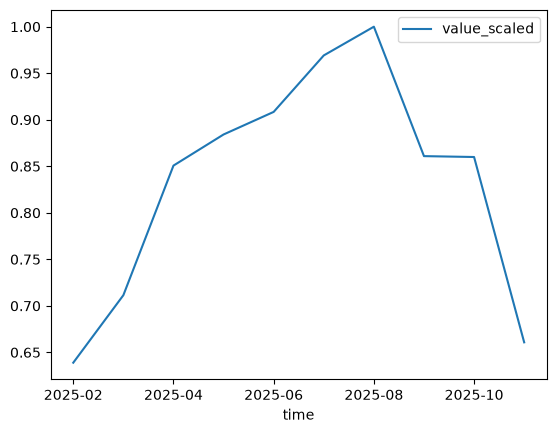

In [17]:
import matplotlib.pyplot as plt

FRANCE = EUROSTAT_AIR_PASSENGERS_MONTHLY_DATA[EUROSTAT_AIR_PASSENGERS_MONTHLY_DATA['geo'] == 'FR']
FR_MAX_PASSENGERS = FRANCE['value'].max()
FR_PEAK_MONTH = FRANCE[FRANCE['value'] == FR_MAX_PASSENGERS]
FRANCE['value_scaled'] = FRANCE['value']/FR_MAX_PASSENGERS
FRANCE.plot(x='time', y=['value_scaled'])

#FR_PEAK_MONTH.time.values[0]
#plt.show()